<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment1/assignment1_streamlined_resnet50_21041015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# STEP 1: Imports and GPU check**

In [ ]:

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GPU available: True
GPU name: Tesla T4
Using device: cuda


**# STEP 2: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


**# STEP 3: Extract dataset zip files**

In [ ]:
dataset_path = "/content/drive/MyDrive/compx525assign1/cell_cultures"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

for f in os.listdir(dataset_path):
    if f.endswith(".zip"):
        zip_path = os.path.join(dataset_path, f)
        print("Extracting:", zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")
print("Extracted folders:", os.listdir(extract_path))



Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/test.zip
Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/train.zip
Extraction complete
Extracted folders: ['train', 'test']


**# STEP 4: DEFINE TRAIN AND TEST PATHS**

In [ ]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
image_exts = (".jpg", ".jpeg", ".png")

classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Folder classes:", classes)
print("Number of folder classes:", len(classes))

print("Usable image counts per class:")
for c in classes:
    cls_path = os.path.join(train_dir, c)
    count = sum(fname.lower().endswith(image_exts) for fname in os.listdir(cls_path))
    print(c, count)

print("Test images:", len([f for f in os.listdir(test_dir) if f.lower().endswith(image_exts)]))


Folder classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of folder classes: 17
Usable image counts per class:
a 1283
b 4
c 475
d 266
e 117
f 59
g 720
h 5
i 199
j 0
k 12
l 660
m 543
n 91
o 197
p 35
q 29
Test images: 512


**# STEP 5: Set train/test paths and count usable images**

In [ ]:
rows = []

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(image_exts):
                rows.append({
                    "filepath": os.path.join(cls_path, fname),
                    "label": cls
                })

train_df = pd.DataFrame(rows)

print(train_df.head())
print("\nTotal usable training images:", len(train_df))
print("\nUsable class counts:")
print(train_df["label"].value_counts().sort_index())

                                   filepath label
0  /content/dataset/train/a/z1303236440.jpg     a
1  /content/dataset/train/a/z1828802943.jpg     a
2  /content/dataset/train/a/z1511796425.jpg     a
3   /content/dataset/train/a/z754212676.jpg     a
4   /content/dataset/train/a/z515075044.jpg     a

Total usable training images: 4695

Usable class counts:
label
a    1283
b       4
c     475
d     266
e     117
f      59
g     720
h       5
i     199
k      12
l     660
m     543
n      91
o     197
p      35
q      29
Name: count, dtype: int64


**# STEP 6: TRAIN / VALIDATION SPLIT**

In [ ]:
class_counts = train_df["label"].value_counts()

# Keep singleton classes in training only
singleton_classes = class_counts[class_counts < 2].index.tolist()
singleton_df = train_df[train_df["label"].isin(singleton_classes)].copy()
normal_df = train_df[~train_df["label"].isin(singleton_classes)].copy()

train_split_df, val_split_df = train_test_split(
    normal_df,
    test_size=0.2,
    stratify=normal_df["label"],
    random_state=42
)

train_split_df = pd.concat([train_split_df, singleton_df], ignore_index=True)

print("Train size:", len(train_split_df))
print("Val size:", len(val_split_df))
print("\nTrain split class counts:")
print(train_split_df["label"].value_counts().sort_index())
print("\nVal split class counts:")
print(val_split_df["label"].value_counts().sort_index())

Train size: 3756
Val size: 939

Train split class counts:
label
a    1026
b       3
c     380
d     213
e      94
f      47
g     576
h       4
i     159
k      10
l     528
m     434
n      73
o     158
p      28
q      23
Name: count, dtype: int64

Val split class counts:
label
a    257
b      1
c     95
d     53
e     23
f     12
g    144
h      1
i     40
k      2
l    132
m    109
n     18
o     39
p      7
q      6
Name: count, dtype: int64


**# STEP 7: ENCODE LABELS**

In [ ]:
label_to_idx = {
    label: idx for idx, label in enumerate(sorted(train_df["label"].unique()))
}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

effective_classes = sorted(label_to_idx.keys())
print("Usable classes:", effective_classes)
print("Number of usable classes:", len(effective_classes))
print("label_to_idx:", label_to_idx)

train_split_df["label_idx"] = train_split_df["label"].map(label_to_idx)
val_split_df["label_idx"] = val_split_df["label"].map(label_to_idx)

print(train_split_df.head())
print(val_split_df.head())

Usable classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of usable classes: 16
label_to_idx: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15}
                                   filepath label  label_idx
0  /content/dataset/train/l/z1595472668.jpg     l         10
1  /content/dataset/train/a/z1619676832.jpg     a          0
2  /content/dataset/train/i/z1221797731.jpg     i          8
3   /content/dataset/train/a/z364383750.jpg     a          0
4  /content/dataset/train/a/z1532810318.jpg     a          0
                                      filepath label  label_idx
2879  /content/dataset/train/g/z1759918639.jpg     g          6
3435   /content/dataset/train/l/z517997486.jpg     l         10
2157   /content/dataset/train/f/z743998935.jpg     f          5
2346   /content/dataset/train/g/z702420011.jpg     g          6
2367  /content/dataset/train/g/z1234212

**# STEP 7.5: IDENTIFY MINORITY CLASSES FROM TRAINING SPLIT**

In [ ]:
train_class_counts = train_split_df["label"].value_counts().sort_index()

print("Train split class counts:")
print(train_class_counts)

# Threshold for minority classes
minority_threshold = 100

minority_classes = train_class_counts[train_class_counts < minority_threshold].index.tolist()

print("\nMinority classes:")
print(minority_classes)

Train split class counts:
label
a    1026
b       3
c     380
d     213
e      94
f      47
g     576
h       4
i     159
k      10
l     528
m     434
n      73
o     158
p      28
q      23
Name: count, dtype: int64

Minority classes:
['b', 'e', 'f', 'h', 'k', 'n', 'p', 'q']


**# STEP 8: IMAGE TRANSFORMS**

In [ ]:
# STEP 8: IMAGE TRANSFORMS WITH IMPROVED AUGMENTATION FOR CELL IMAGES

# Normal transform — vertical flip and rotation added (cells have no fixed orientation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Stronger transform for minority classes
minority_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation stays deterministic
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

**# STEP 9: PYTORCH DATASETS AND DATA LOADERS**

In [ ]:
# STEP 9: PYTORCH DATASETS AND DATA LOADERS

class ImageDataset(Dataset):
    def __init__(self, df, transform=None, minority_transform=None, minority_classes=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.minority_transform = minority_transform
        self.minority_classes = set(minority_classes) if minority_classes is not None else set()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        label = self.df.loc[idx, "label_idx"]
        label_name = self.df.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if label_name in self.minority_classes and self.minority_transform is not None:
            image = self.minority_transform(image)
        elif self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = ImageDataset(
    train_split_df,
    transform=train_transform,
    minority_transform=minority_train_transform,
    minority_classes=minority_classes
)

val_dataset = ImageDataset(
    val_split_df,
    transform=val_transform
)

# --- Class weights for CrossEntropyLoss ---
class_counts_sorted = train_split_df["label_idx"].value_counts().sort_index()
loss_class_weights = 1.0 / torch.tensor(class_counts_sorted.values, dtype=torch.float)
loss_class_weights = loss_class_weights / loss_class_weights.sum() * len(loss_class_weights)
loss_class_weights = loss_class_weights.to(device)
print("CrossEntropyLoss class weights:", loss_class_weights)

# --- WeightedRandomSampler: oversample minority classes ---
sampler_weights = loss_class_weights.cpu()[train_split_df["label_idx"].values]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sampler_weights,
    num_samples=len(sampler_weights),
    replacement=True
)

# Use sampler instead of shuffle=True
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 3756
Validation dataset size: 939


**# STEP 10: LOAD PRETRAINED RESNET50 AND REPLACE FINAL LAYER**

In [ ]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
num_classes = len(label_to_idx)

# Replace fc with Dropout + Linear to reduce overfitting
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

print(model.fc)

# Shared save path used across all phases
best_model_path = "/content/drive/MyDrive/resnet50_best_model_21041015.pth"


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


Linear(in_features=2048, out_features=16, bias=True)


**# STEP 11: PHASE 1 TRAINING - TRAIN FINAL LAYER ONLY**

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(weight=loss_class_weights)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=3e-4, weight_decay=1e-4)

num_epochs = 7
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print("Trainable parameters in phase 1:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "best_val_acc": best_val_acc
        }, best_model_path)
        print(f"  --> Saved new best model at epoch {epoch+1} (val_acc={val_acc:.4f})")

    print(f"Phase 1 | Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("Phase 1 best val acc:", best_val_acc)

Trainable parameters in phase 1:
fc.weight
fc.bias
Phase 1 | Epoch 1/7 | Train Loss: 2.1445 | Train Acc: 0.2742 | Val Acc: 0.2854
Phase 1 | Epoch 2/7 | Train Loss: 1.9327 | Train Acc: 0.3222 | Val Acc: 0.3163
Phase 1 | Epoch 3/7 | Train Loss: 1.8052 | Train Acc: 0.3805 | Val Acc: 0.3440
Phase 1 | Epoch 4/7 | Train Loss: 1.7161 | Train Acc: 0.4236 | Val Acc: 0.3845
Phase 1 | Epoch 5/7 | Train Loss: 1.6513 | Train Acc: 0.4462 | Val Acc: 0.3994
Phase 1 | Epoch 6/7 | Train Loss: 1.5879 | Train Acc: 0.4758 | Val Acc: 0.4068
Phase 1 | Epoch 7/7 | Train Loss: 1.5315 | Train Acc: 0.5005 | Val Acc: 0.4271


**# STEP 12: PHASE 2 FINE-TUNING - TRAIN LAYER4 + FC AND SAVE BEST MODEL**

In [ ]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 AND layer4 (more capacity for cell-specific features)
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# LR is 30x lower than phase 1 — critical to avoid destroying pretrained weights
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

num_epochs = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print("Trainable parameters in phase 2:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "best_val_acc": best_val_acc
        }, best_model_path)
        print(f"  --> Saved new best model at epoch {epoch+1} (val_acc={val_acc:.4f})")

    print(f"Phase 2 | Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("Best val acc after phase 2:", best_val_acc)
print("Best model saved to:", best_model_path)

Trainable parameters in phase 2:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias
Saved new best phase-2 model at epoch 1
Phase 2 | Epoch 1/7 | Train Loss: 1.1513 | Train Acc: 0.6182 | Val Acc: 0.6177
Saved new best phase-2 model at epoch 2
Phase 2 | Epoch 2/7 | Train Loss: 0.5283 | Train Acc: 0.8355 | Val Acc: 0.6209
Phase 2 | Epoch 3/7 | Train Loss: 0.2618 | Train Acc: 0.9313 | Val Acc: 0.6187
Phase 2

**# STEP 13: VALIDATION EVALUATION**

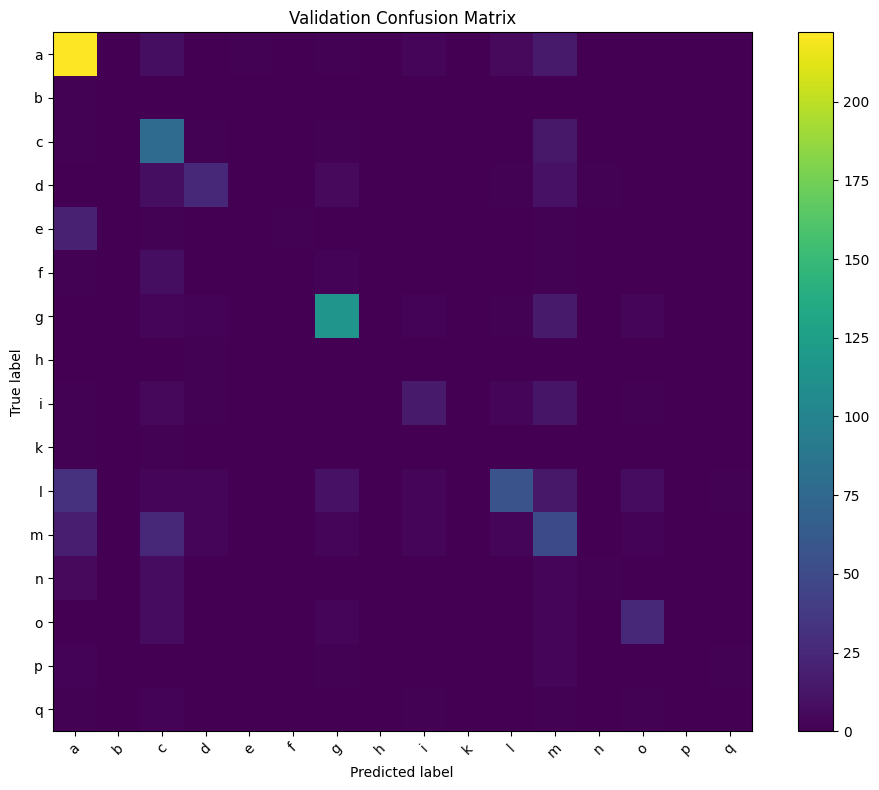

              precision    recall  f1-score   support

           a       0.72      0.86      0.79       257
           b       0.00      0.00      0.00         1
           c       0.49      0.82      0.62        95
           d       0.70      0.49      0.58        53
           e       0.00      0.00      0.00        23
           f       0.00      0.00      0.00        12
           g       0.81      0.81      0.81       144
           h       0.00      0.00      0.00         1
           i       0.57      0.40      0.47        40
           k       0.00      0.00      0.00         2
           l       0.79      0.43      0.56       132
           m       0.34      0.46      0.39       109
           n       0.50      0.06      0.10        18
           o       0.64      0.64      0.64        39
           p       0.00      0.00      0.00         7
           q       0.00      0.00      0.00         6

    accuracy                           0.63       939
   macro avg       0.35   

In [ ]:
# STEP 13: VALIDATION EVALUATION USING SAVED BEST MODEL

model_eval = resnet50(weights=None)
model_eval.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model_eval.fc.in_features, len(label_to_idx))
)

checkpoint = torch.load(best_model_path, map_location=device)
model_eval.load_state_dict(checkpoint["model_state_dict"])
model_eval = model_eval.to(device)
model_eval.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_eval(images)
        _, preds = torch.max(outputs, 1)
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Validation Confusion Matrix")
plt.colorbar()

class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(all_true, all_pred, target_names=class_names, zero_division=0))
print("Loaded from:", best_model_path, "| Best val acc:", checkpoint["best_val_acc"])

**# STEP 14: CREATE TEST DATAFRAME AND TEST DATALOADER**

In [ ]:
test_rows = []

for fname in sorted(os.listdir(test_dir)):
    if fname.lower().endswith(image_exts):
        test_rows.append({
            "filepath": os.path.join(test_dir, fname),
            "filename": fname
        })

test_df = pd.DataFrame(test_rows)
print(test_df.head())
print("Total test images:", len(test_df))


class TestImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        filename = self.df.loc[idx, "filename"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename


test_dataset = TestImageDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test dataset size:", len(test_dataset))

                                filepath         filename
0    /content/dataset/test/z10002793.jpg    z10002793.jpg
1  /content/dataset/test/z1002467769.jpg  z1002467769.jpg
2  /content/dataset/test/z1002525907.jpg  z1002525907.jpg
3  /content/dataset/test/z1004350237.jpg  z1004350237.jpg
4   /content/dataset/test/z100756404.jpg   z100756404.jpg
Total test images: 512
Test dataset size: 512


**# STEP 15: GENERATE TEST PREDICTION CSV**

In [ ]:
# STEP 15: GENERATE TEST PREDICTION CSV USING SAVED BEST MODEL

model_test = resnet50(weights=None)
model_test.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model_test.fc.in_features, len(label_to_idx))
)

checkpoint = torch.load(best_model_path, map_location=device)
model_test.load_state_dict(checkpoint["model_state_dict"])
model_test = model_test.to(device)
model_test.eval()

all_filenames = []
all_pred_labels = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model_test(images)
        _, preds = torch.max(outputs, 1)
        pred_labels = [idx_to_label[p.item()] for p in preds]
        all_filenames.extend(filenames)
        all_pred_labels.extend(pred_labels)

submission_df = pd.DataFrame({
    "TestFileName": all_filenames,
    "Class": all_pred_labels
})

csv_path = "/content/drive/MyDrive/resnet50_submission_best_improved.csv"
submission_df.to_csv(csv_path, index=False)

print(submission_df.head())
print("Saved to:", csv_path)

      TestFileName Class
0    z10002793.jpg     a
1  z1002467769.jpg     a
2  z1002525907.jpg     a
3  z1004350237.jpg     c
4   z100756404.jpg     i
Saved to: /content/drive/MyDrive/resnet50_submission_3_minority_aug.csv


**# STEP 16: CLASS-WEIGHTED LOSS — SUMMARY**

In [ ]:

# (Weights computed in Step 9 and applied in Steps 11 & 12)

print("Class weights used for CrossEntropyLoss:")
for idx, cls in idx_to_label.items():
    print(f"  [{idx}] {cls}: {loss_class_weights[idx].item():.4f}")

**# STEP 17: PHASE 3 — FULL MODEL FINE-TUNING (all layers, very low LR, weighted loss)**

In [ ]:

# Unfreeze everything for a final low-LR pass

for param in model.parameters():
    param.requires_grad = True

optimizer_p3 = torch.optim.Adam(
    model.parameters(),
    lr=3e-6,           # 3x lower than phase 2 — very conservative
    weight_decay=1e-4
)

num_epochs_p3 = 7
scheduler_p3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p3, T_max=num_epochs_p3)

# Load best model from phases 1+2 as starting point
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print(f"Starting Phase 3 from best val acc: {checkpoint['best_val_acc']:.4f}")

for epoch in range(num_epochs_p3):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_p3.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_p3.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    scheduler_p3.step()
    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "best_val_acc": best_val_acc
        }, best_model_path)
        print(f"  --> Saved new best model at phase3 epoch {epoch+1} (val_acc={val_acc:.4f})")

    print(f"Phase 3 | Epoch {epoch+1}/{num_epochs_p3} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {scheduler_p3.get_last_lr()[0]:.2e}")

print("Best val acc after phase 3:", best_val_acc)
print("Best model saved to:", best_model_path)

**# STEP 18: EVALUATE BEST MODEL ON VALIDATION (best across all 3 phases)**

In [ ]:
# STEP 18: EVALUATE BEST MODEL ON VALIDATION (best across all 3 phases)

model_final = resnet50(weights=None)
model_final.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model_final.fc.in_features, len(label_to_idx))
)

checkpoint = torch.load(best_model_path, map_location=device)
model_final.load_state_dict(checkpoint["model_state_dict"])
model_final = model_final.to(device)
model_final.eval()

print(f"Evaluating model with best val acc: {checkpoint['best_val_acc']:.4f}")

all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_final(images)
        _, preds = torch.max(outputs, 1)
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true, all_pred)
class_names = [idx_to_label[i] for i in range(len(idx_to_label))]

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Final Validation Confusion Matrix (Best Model)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print(classification_report(all_true, all_pred, target_names=class_names, zero_division=0))


**# STEP 19: GENERATE FINAL TEST CSV USING BEST MODEL (across all phases)**

In [ ]:


model_final.eval()
all_filenames = []
all_pred_labels = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)
        outputs = model_final(images)
        _, preds = torch.max(outputs, 1)
        pred_labels = [idx_to_label[p.item()] for p in preds]
        all_filenames.extend(filenames)
        all_pred_labels.extend(pred_labels)

submission_df = pd.DataFrame({
    "TestFileName": all_filenames,
    "Class": all_pred_labels
})

final_csv_path = "/content/drive/MyDrive/resnet50_submission_final_3phase.csv"
submission_df.to_csv(final_csv_path, index=False)

print(submission_df.head())
print("Final submission saved to:", final_csv_path)